In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd

from skimage.metrics import (
    mean_squared_error,
    peak_signal_noise_ratio,
    structural_similarity
)

print("Libraries imported successfully")

Libraries imported successfully


In [1]:
try:
    from google.colab import files
    uploaded = files.upload()
except Exception:
    import glob
    degraded_files = sorted(glob.glob('dataset/degraded/*.bmp') or glob.glob('Historical_Document_Project/dataset/DIBCO2018/degraded/*.bmp') or glob.glob('*.bmp'))
    uploaded = {f: None for f in degraded_files}
    print(f'Loaded {len(uploaded)} local degraded images.')

Saving 1.bmp to 1.bmp
Saving 2.bmp to 2.bmp
Saving 3.bmp to 3.bmp
Saving 4.bmp to 4.bmp
Saving 5.bmp to 5.bmp
Saving 6.bmp to 6.bmp
Saving 7.bmp to 7.bmp
Saving 8.bmp to 8.bmp
Saving 9.bmp to 9.bmp
Saving 10.bmp to 10.bmp


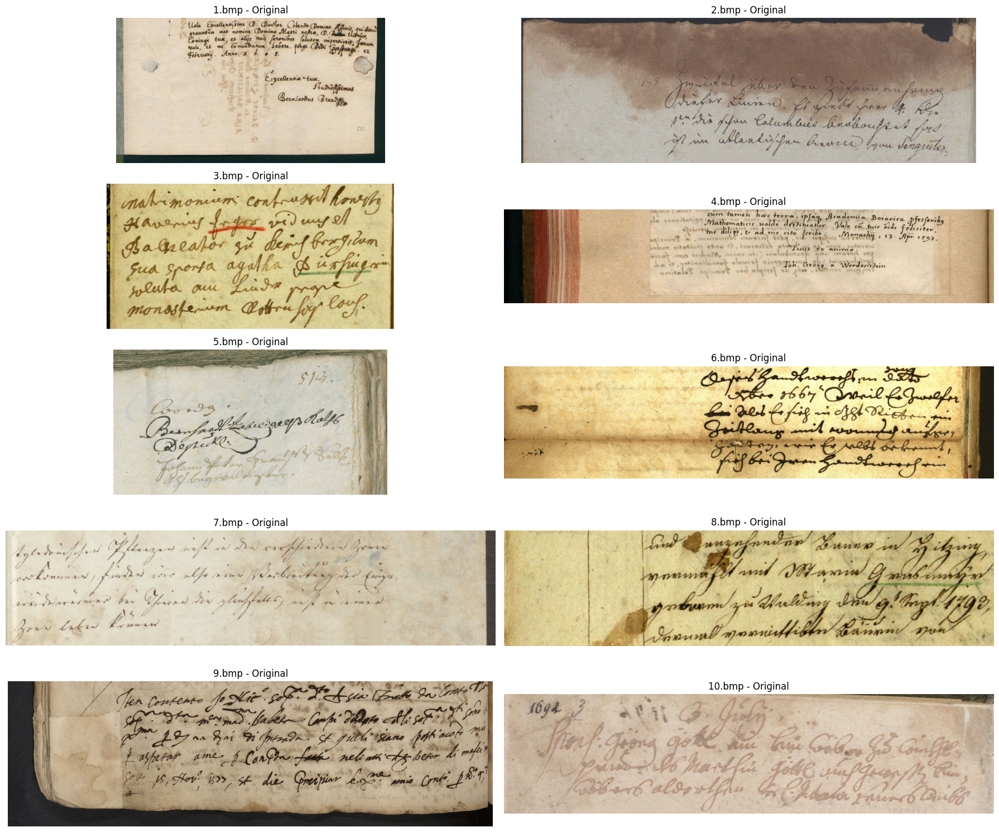

In [109]:
import cv2
import os
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 15))
for i in range(1, 11):
    path = f"{i}.bmp"
    if not os.path.exists(path):
        for candidate in [f"dataset/degraded/{i}.bmp", f"Historical_Document_Project/dataset/DIBCO2018/degraded/{i}.bmp"]:
            if os.path.exists(candidate):
                path = candidate
                break
    image = cv2.imread(path)
    if image is None:
        continue
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.subplot(5, 2, i)
    plt.imshow(image_rgb)
    plt.title(f"{i}.bmp - Original")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [2]:
import os

folders = [
    "member1_results",
    "member1_results/grayscale",
    "member1_results/normalized",
    "member1_results/filtered",
    "member1_results/enhanced",
    "member1_results/comparisons"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Processing folders created.")

Processing folders created.


## Grayscale Conversion

The original DIBCO 2018 document images are RGB images. Since the subsequent preprocessing operations mainly depend on image intensity, the RGB images are converted into grayscale images.

The grayscale images are saved separately without modifying the original dataset.

In [3]:
import cv2
import os

for filename in uploaded.keys():
    image = cv2.imread(filename)
    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )
    base_name = os.path.splitext(filename)[0]
    output_path = (
        f"member1_results/grayscale/"
        f"{base_name}_gray.bmp"
    )
    cv2.imwrite(output_path, gray)

print("Grayscale conversion completed.")

Grayscale conversion completed.


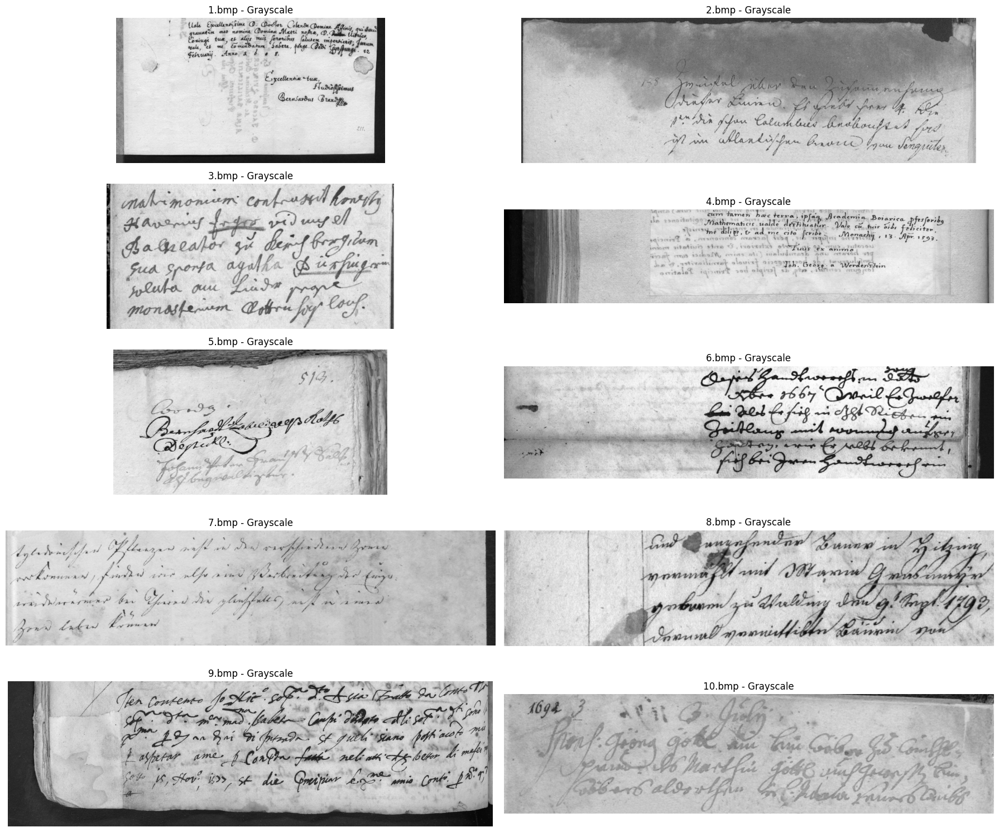

In [102]:
plt.figure(figsize=(18, 15))

for i in range(1, 11):

    path = (
        f"member1_results/grayscale/"
        f"{i}_gray.bmp"
    )

    image = cv2.imread(
        path,
        cv2.IMREAD_GRAYSCALE
    )

    plt.subplot(5, 2, i)

    plt.imshow(
        image,
        cmap="gray"
    )

    plt.title(f"{i}.bmp - Grayscale")

    plt.axis("off")

plt.tight_layout()
plt.show()

## Image Normalization

The grayscale document images are normalized to provide a consistent intensity range for subsequent image-processing operations. Min-max normalization is used to map the intensity values between 0 and 1. For image storage and visualization, the normalized values are converted back to the 8-bit range (0–255).

The original grayscale images are preserved, and the normalized results are saved separately.

In [7]:
try:
    from google.colab import files
    uploaded_gray = files.upload()
except Exception:
    import glob
    gray_files = sorted(glob.glob('member1_results/grayscale/*.bmp') or glob.glob('Historical_Document_Project/member1_results/grayscale/*.bmp'))
    uploaded_gray = {f: None for f in gray_files}
    print(f'Loaded {len(uploaded_gray)} grayscale images.')

Saving 8_gray.bmp to 8_gray.bmp
Saving 9_gray.bmp to 9_gray.bmp
Saving 10_gray.bmp to 10_gray.bmp
Saving 1_gray.bmp to 1_gray.bmp
Saving 2_gray.bmp to 2_gray.bmp
Saving 3_gray.bmp to 3_gray.bmp
Saving 4_gray.bmp to 4_gray.bmp
Saving 5_gray.bmp to 5_gray.bmp
Saving 6_gray.bmp to 6_gray.bmp
Saving 7_gray.bmp to 7_gray.bmp


In [8]:
import os

os.makedirs("member1_results/normalized", exist_ok=True)

print("Normalization folder created.")

Normalization folder created.


In [9]:
input_folder = "."

output_folder = "member1_results/normalized"

os.makedirs(output_folder, exist_ok=True)

for filename in uploaded_gray.keys():

    image = cv2.imread(
        filename,
        cv2.IMREAD_GRAYSCALE
    )
    normalized = cv2.normalize(
        image,
        None,
        alpha=0,
        beta=255,
        norm_type=cv2.NORM_MINMAX
    )
    base_name = os.path.splitext(filename)[0]
    output_path = os.path.join(
        output_folder,
        base_name.replace("_gray", "") + "_normalized.bmp"
    )
    cv2.imwrite(
        output_path,
        normalized
    )

print("Normalization completed for all images.")

Normalization completed for all images.


In [10]:
normalized_files = os.listdir("member1_results/normalized")
print("Number of normalized images:",len(normalized_files))
print(normalized_files)

Number of normalized images: 10
['2_normalized.bmp', '7_normalized.bmp', '6_normalized.bmp', '1_normalized.bmp', '8_normalized.bmp', '9_normalized.bmp', '10_normalized.bmp', '4_normalized.bmp', '3_normalized.bmp', '5_normalized.bmp']


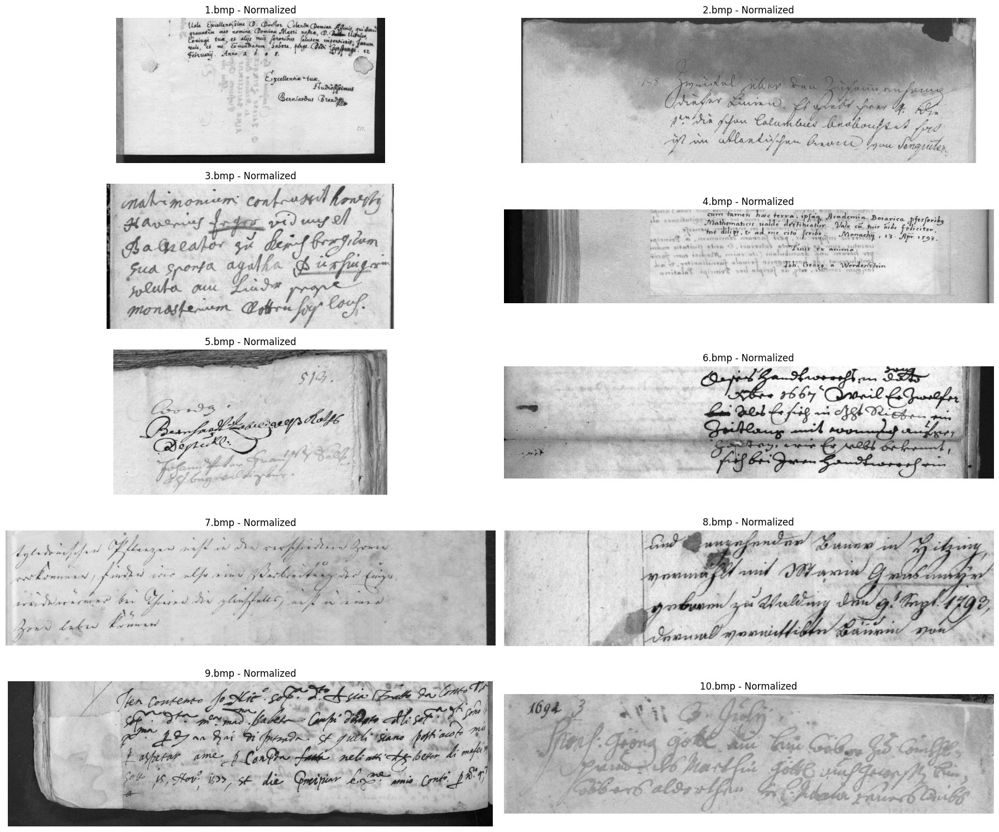

In [13]:
plt.figure(figsize=(18, 15))

for i in range(1, 11):

    path = (
        f"member1_results/normalized/"
        f"{i}_normalized.bmp"
    )

    image = cv2.imread(
        path,
        cv2.IMREAD_GRAYSCALE
    )

    plt.subplot(5, 2, i)

    plt.imshow(
        image,
        cmap="gray"
    )

    plt.title(f"{i}.bmp - Normalized")

    plt.axis("off")

plt.tight_layout()
plt.show()

## Noise Filtering

Noise filtering is applied to the normalized historical document images to reduce unwanted image noise while preserving important text structures.
Two classical spatial filtering techniques are evaluated:
1. Median filtering
2. Gaussian filtering

Kernel sizes of 3×3 and 5×5 are tested for both methods. The filtered images are saved separately for comparison.

In [16]:
try:
    from google.colab import files
    uploaded_normalized = files.upload()
except Exception:
    import glob
    norm_files = sorted(glob.glob('member1_results/normalized/*.bmp') or glob.glob('Historical_Document_Project/member1_results/normalized/*.bmp'))
    uploaded_normalized = {f: None for f in norm_files}
    print(f'Loaded {len(uploaded_normalized)} normalized images.')

Saving 2_normalized.bmp to 2_normalized.bmp
Saving 3_normalized.bmp to 3_normalized.bmp
Saving 4_normalized.bmp to 4_normalized.bmp
Saving 5_normalized.bmp to 5_normalized.bmp
Saving 6_normalized.bmp to 6_normalized.bmp
Saving 7_normalized.bmp to 7_normalized.bmp
Saving 8_normalized.bmp to 8_normalized.bmp
Saving 9_normalized.bmp to 9_normalized.bmp
Saving 10_normalized.bmp to 10_normalized.bmp
Saving 1_normalized.bmp to 1_normalized.bmp


In [17]:
import os
filter_folders = [
    "member1_results/filtered",
    "member1_results/filtered/median_3x3",
    "member1_results/filtered/median_5x5",
    "member1_results/filtered/gaussian_3x3",
    "member1_results/filtered/gaussian_5x5"
]
for folder in filter_folders:
    os.makedirs(folder, exist_ok=True)
print("Filtering folders created.")

Filtering folders created.


In [18]:
import cv2
import os
import matplotlib.pyplot as plt

norm_path = '1_normalized.bmp'
if not os.path.exists(norm_path):
    for c in ['member1_results/normalized/1_normalized.bmp', 'Historical_Document_Project/member1_results/normalized/1_normalized.bmp']:
        if os.path.exists(c):
            norm_path = c
            break

image = cv2.imread(norm_path, cv2.IMREAD_GRAYSCALE)
if image is not None:
    print('Image shape:', image.shape)
    print('Minimum:', image.min())
    print('Maximum:', image.max())
else:
    print('1_normalized.bmp not yet generated.')

Image shape: (811, 1504)
Minimum: 0
Maximum: 255


In [19]:
median_3 = cv2.medianBlur(image,3)

In [20]:
cv2.imwrite(
    "member1_results/filtered/median_3x3/1_median_3x3.bmp",
    median_3
)
print("Median 3×3 completed.")

Median 3×3 completed.


In [21]:
median_5 = cv2.medianBlur(
    image,
    5
)
cv2.imwrite(
    "member1_results/filtered/median_5x5/1_median_5x5.bmp",
    median_5
)
print("Median 5×5 completed.")

Median 5×5 completed.


In [22]:
gaussian_3 = cv2.GaussianBlur(
    image,
    (3, 3),
    0
)
cv2.imwrite(
    "member1_results/filtered/gaussian_3x3/1_gaussian_3x3.bmp",
    gaussian_3
)
print("Gaussian 3×3 completed.")

Gaussian 3×3 completed.


In [23]:
gaussian_5 = cv2.GaussianBlur(
    image,
    (5, 5),
    0
)
cv2.imwrite(
    "member1_results/filtered/gaussian_5x5/1_gaussian_5x5.bmp",
    gaussian_5
)
print("Gaussian 5×5 completed.")

Gaussian 5×5 completed.


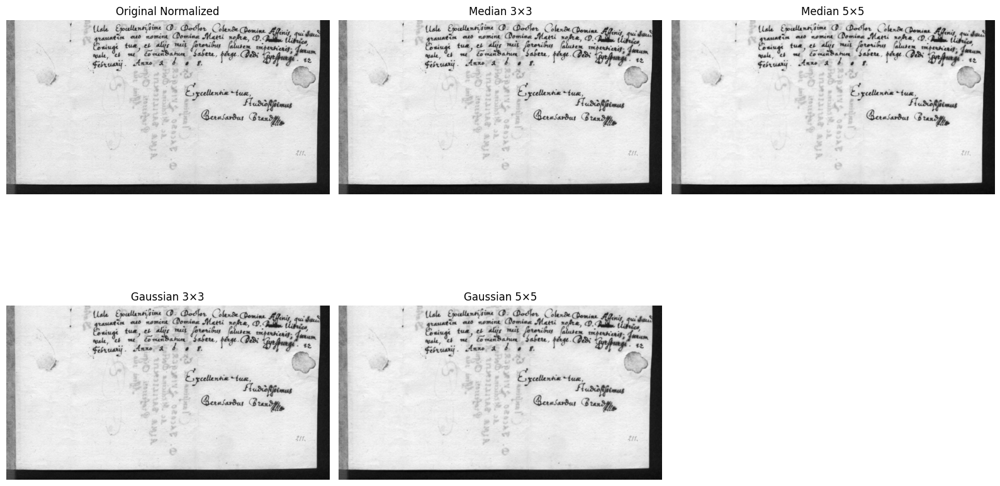

In [24]:
plt.figure(figsize=(16, 10))

plt.subplot(2, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Normalized")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(median_3, cmap="gray")
plt.title("Median 3×3")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(median_5, cmap="gray")
plt.title("Median 5×5")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(gaussian_3, cmap="gray")
plt.title("Gaussian 3×3")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(gaussian_5, cmap="gray")
plt.title("Gaussian 5×5")
plt.axis("off")

plt.tight_layout()
plt.show()

In [26]:
import os
import cv2

output_base = "member1_results/filtered"
for filename in uploaded_normalized.keys():
    image = cv2.imread(
        filename,
        cv2.IMREAD_GRAYSCALE
    )
    base_name = os.path.splitext(filename)[0]
    number = base_name.replace("_normalized", "")

    # Median 3×3
    median_3 = cv2.medianBlur(image, 3)
    cv2.imwrite(
        f"{output_base}/median_3x3/{number}_median_3x3.bmp",
        median_3
    )

    # Median 5×5
    median_5 = cv2.medianBlur(image, 5)
    cv2.imwrite(
        f"{output_base}/median_5x5/{number}_median_5x5.bmp",
        median_5
    )

    # Gaussian 3×3
    gaussian_3 = cv2.GaussianBlur(
        image,
        (3, 3),
        0
    )
    cv2.imwrite(
        f"{output_base}/gaussian_3x3/{number}_gaussian_3x3.bmp",
        gaussian_3
    )

    # Gaussian 5×5
    gaussian_5 = cv2.GaussianBlur(
        image,
        (5, 5),
        0
    )
    cv2.imwrite(
        f"{output_base}/gaussian_5x5/{number}_gaussian_5x5.bmp",
        gaussian_5
    )
print("Filtering completed for all 10 images.")

Filtering completed for all 10 images.


In [27]:
for folder in filter_folders[1:]:
    files_in_folder = os.listdir(folder)

    print(
        folder,
        "→",
        len(files_in_folder),
        "images"
    )

member1_results/filtered/median_3x3 → 10 images
member1_results/filtered/median_5x5 → 10 images
member1_results/filtered/gaussian_3x3 → 10 images
member1_results/filtered/gaussian_5x5 → 10 images


## Contrast Enhancement
The filtered document images are enhanced to improve the visibility of faint text and increase the distinction between foreground characters and the document background. Classical contrast-enhancement techniques, including histogram equalization, contrast stretching, and CLAHE, are applied and compared across the document images.

In [45]:
import os

enhancement_folders = [
    "member1_results/enhanced",
    "member1_results/enhanced/histogram_equalization",
    "member1_results/enhanced/contrast_stretching",
    "member1_results/enhanced/clahe",
    "member1_results/enhanced/comparisons"
]

for folder in enhancement_folders:
    os.makedirs(folder, exist_ok=True)

print("All enhancement folders created successfully.")

All enhancement folders created successfully.


In [62]:
try:
    from google.colab import files
    uploaded_filtered = files.upload()
except Exception:
    import glob
    filt_files = sorted(glob.glob('member1_results/filtered/median_3/*.bmp') or glob.glob('Historical_Document_Project/member1_results/filtered/median_3/*.bmp'))
    uploaded_filtered = {f: None for f in filt_files}
    print(f'Loaded {len(uploaded_filtered)} filtered images.')

Saving 1_median_3x3.bmp to 1_median_3x3 (1).bmp
Saving 2_median_3x3.bmp to 2_median_3x3 (1).bmp
Saving 3_median_3x3.bmp to 3_median_3x3 (1).bmp
Saving 4_median_3x3.bmp to 4_median_3x3 (1).bmp
Saving 5_median_3x3.bmp to 5_median_3x3 (1).bmp
Saving 6_median_3x3.bmp to 6_median_3x3 (1).bmp
Saving 7_median_3x3.bmp to 7_median_3x3 (1).bmp
Saving 8_median_3x3.bmp to 8_median_3x3 (1).bmp
Saving 9_median_3x3.bmp to 9_median_3x3 (1).bmp
Saving 10_median_3x3.bmp to 10_median_3x3 (1).bmp


In [63]:
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np

med_path = '1_median_3x3.bmp'
if not os.path.exists(med_path):
    for c in ['member1_results/filtered/median_3/1_median_3x3.bmp', 'Historical_Document_Project/member1_results/filtered/median_3/1_median_3x3.bmp']:
        if os.path.exists(c):
            med_path = c
            break

image = cv2.imread(med_path, cv2.IMREAD_GRAYSCALE)
if image is not None:
    print('Shape:', image.shape)
    print('Minimum:', image.min())
    print('Maximum:', image.max())
else:
    print('1_median_3x3.bmp not yet generated.')

Shape: (811, 1504)
Minimum: 4
Maximum: 249


## Histogram Equalization
Histogram equalization redistributes the image intensity values to improve overall contrast. It helps make faint text more visible by spreading frequently occurring intensity levels across a wider range.

In [64]:
hist_eq = cv2.equalizeHist(image)

In [65]:
cv2.imwrite(
    "member1_results/enhanced/histogram_equalization/1_hist_eq.bmp",
    hist_eq
)

print("Histogram equalization completed.")

Histogram equalization completed.


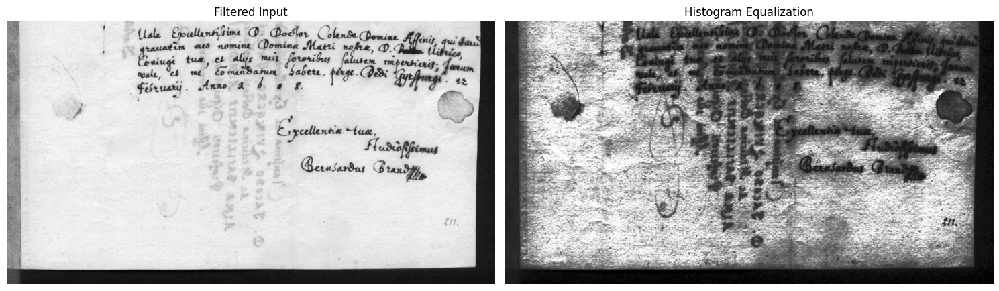

In [66]:
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Filtered Input")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(hist_eq, cmap="gray")
plt.title("Histogram Equalization")
plt.axis("off")

plt.tight_layout()
plt.show()

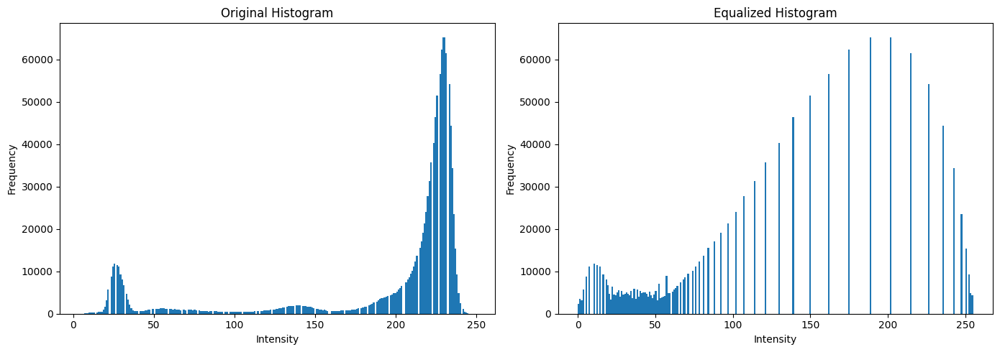

In [67]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(image.ravel(), bins=256)
plt.title("Original Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(hist_eq.ravel(), bins=256)
plt.title("Equalized Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Contrast Stretching
Contrast stretching expands the existing intensity range of the image to a broader range, typically from 0 to 255. It improves the distinction between dark text and lighter background regions.

In [68]:
min_val = np.min(image)
max_val = np.max(image)
contrast_stretched = (
    (image - min_val) *
    255.0 /
    (max_val - min_val)
)
contrast_stretched = np.clip(
    contrast_stretched,
    0,
    255
).astype(np.uint8)

In [69]:
cv2.imwrite(
    "member1_results/enhanced/contrast_stretching/1_contrast_stretch.bmp",
    contrast_stretched
)

print("Contrast stretching completed.")

Contrast stretching completed.


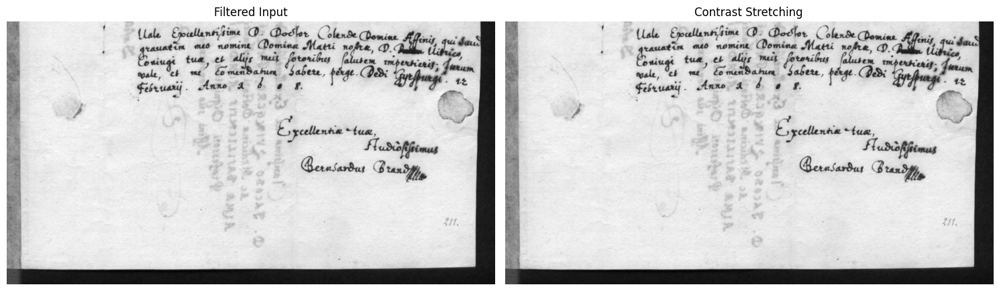

In [70]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Filtered Input")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(
    contrast_stretched,
    cmap="gray"
)
plt.title("Contrast Stretching")
plt.axis("off")

plt.tight_layout()
plt.show()

### CLAHE
Contrast Limited Adaptive Histogram Equalization (CLAHE) improves contrast locally by applying histogram equalization to small image regions. A contrast limit is used to reduce excessive enhancement of noise and background artifacts, making it useful for documents with uneven illumination.

In [71]:
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)

clahe_result = clahe.apply(image)

In [72]:
cv2.imwrite(
    "member1_results/enhanced/clahe/1_clahe.bmp",
    clahe_result
)

print("CLAHE completed.")

CLAHE completed.


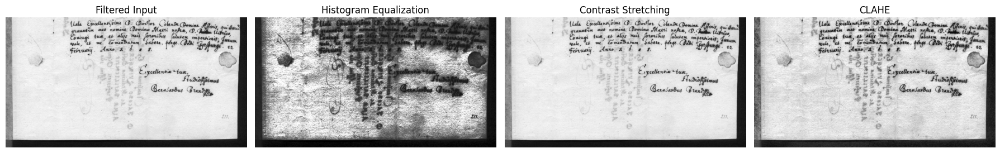

In [73]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 4, 1)
plt.imshow(image, cmap="gray")
plt.title("Filtered Input")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(hist_eq, cmap="gray")
plt.title("Histogram Equalization")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(
    contrast_stretched,
    cmap="gray"
)
plt.title("Contrast Stretching")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(
    clahe_result,
    cmap="gray"
)
plt.title("CLAHE")
plt.axis("off")

plt.tight_layout()
plt.show()

In [81]:
for filename in uploaded_filtered.keys():

    image = cv2.imread(
        filename,
        cv2.IMREAD_GRAYSCALE
    )

    base_name = os.path.splitext(filename)[0]

    # Histogram Equalization
    hist_eq = cv2.equalizeHist(image)

    cv2.imwrite(
        f"member1_results/enhanced/"
        f"histogram_equalization/"
        f"{base_name}_hist_eq.bmp",
        hist_eq
    )

    # Contrast Stretching
    min_val = np.min(image)
    max_val = np.max(image)

    if max_val > min_val:
        contrast_stretched = (
            (image - min_val) *
            255.0 /
            (max_val - min_val)
        )
    else:
        contrast_stretched = image.copy()

    contrast_stretched = np.clip(
        contrast_stretched,
        0,
        255
    ).astype(np.uint8)

    cv2.imwrite(
        f"member1_results/enhanced/"
        f"contrast_stretching/"
        f"{base_name}_contrast_stretch.bmp",
        contrast_stretched
    )

    # CLAHE
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    clahe_result = clahe.apply(image)

    cv2.imwrite(
        f"member1_results/enhanced/"
        f"clahe/"
        f"{base_name}_clahe.bmp",
        clahe_result
    )

print("Contrast enhancement completed for all 10 images.")

Contrast enhancement completed for all 10 images.


In [82]:
folders = [
    "member1_results/enhanced/histogram_equalization",
    "member1_results/enhanced/contrast_stretching",
    "member1_results/enhanced/clahe"
]

for folder in folders:
    print(folder, "→", len(os.listdir(folder)), "images")

member1_results/enhanced/histogram_equalization → 10 images
member1_results/enhanced/contrast_stretching → 10 images
member1_results/enhanced/clahe → 10 images


In [85]:
import os

folders = [
    "member1_results/enhanced/histogram_equalization",
    "member1_results/enhanced/contrast_stretching",
    "member1_results/enhanced/clahe"
]

for folder in folders:
    print("\n", folder)
    print("Number of images:", len(os.listdir(folder)))
    print(sorted(os.listdir(folder)))


 member1_results/enhanced/histogram_equalization
Number of images: 10
['10_median_3x3 (1)_hist_eq.bmp', '1_median_3x3 (1)_hist_eq.bmp', '2_median_3x3 (1)_hist_eq.bmp', '3_median_3x3 (1)_hist_eq.bmp', '4_median_3x3 (1)_hist_eq.bmp', '5_median_3x3 (1)_hist_eq.bmp', '6_median_3x3 (1)_hist_eq.bmp', '7_median_3x3 (1)_hist_eq.bmp', '8_median_3x3 (1)_hist_eq.bmp', '9_median_3x3 (1)_hist_eq.bmp']

 member1_results/enhanced/contrast_stretching
Number of images: 10
['10_median_3x3 (1)_contrast_stretch.bmp', '1_median_3x3 (1)_contrast_stretch.bmp', '2_median_3x3 (1)_contrast_stretch.bmp', '3_median_3x3 (1)_contrast_stretch.bmp', '4_median_3x3 (1)_contrast_stretch.bmp', '5_median_3x3 (1)_contrast_stretch.bmp', '6_median_3x3 (1)_contrast_stretch.bmp', '7_median_3x3 (1)_contrast_stretch.bmp', '8_median_3x3 (1)_contrast_stretch.bmp', '9_median_3x3 (1)_contrast_stretch.bmp']

 member1_results/enhanced/clahe
Number of images: 10
['10_median_3x3 (1)_clahe.bmp', '1_median_3x3 (1)_clahe.bmp', '2_median_3

In [86]:
import os

comparison_folder = "member1_results/enhanced/comparisons"

os.makedirs(comparison_folder, exist_ok=True)

print("Comparison folder ready.")

Comparison folder ready.


In [87]:
import glob

hist_files = sorted(
    glob.glob(
        "member1_results/enhanced/histogram_equalization/*.bmp"
    )
)
stretch_files = sorted(
    glob.glob(
        "member1_results/enhanced/contrast_stretching/*.bmp"
    )
)
clahe_files = sorted(
    glob.glob(
        "member1_results/enhanced/clahe/*.bmp"
    )
)
print("Histogram:", len(hist_files))
print("Stretching:", len(stretch_files))
print("CLAHE:", len(clahe_files))

Histogram: 10
Stretching: 10
CLAHE: 10


In [88]:
import cv2
import matplotlib.pyplot as plt

hist1 = cv2.imread(
    hist_files[0],
    cv2.IMREAD_GRAYSCALE
)
stretch1 = cv2.imread(
    stretch_files[0],
    cv2.IMREAD_GRAYSCALE
)
clahe1 = cv2.imread(
    clahe_files[0],
    cv2.IMREAD_GRAYSCALE
)

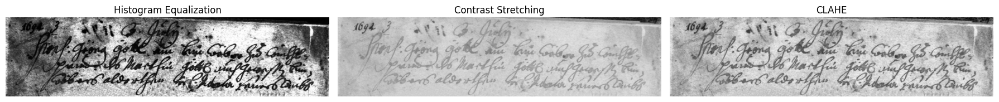

In [89]:
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.imshow(hist1, cmap="gray")
plt.title("Histogram Equalization")
plt.axis("off")
plt.subplot(1, 3, 2)
plt.imshow(stretch1, cmap="gray")
plt.title("Contrast Stretching")
plt.axis("off")
plt.subplot(1, 3, 3)
plt.imshow(clahe1, cmap="gray")
plt.title("CLAHE")
plt.axis("off")
plt.tight_layout()
plt.show()

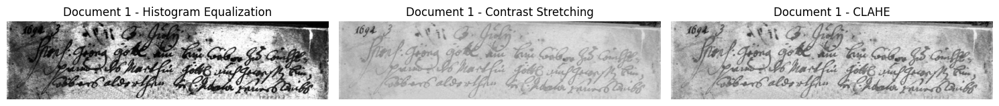

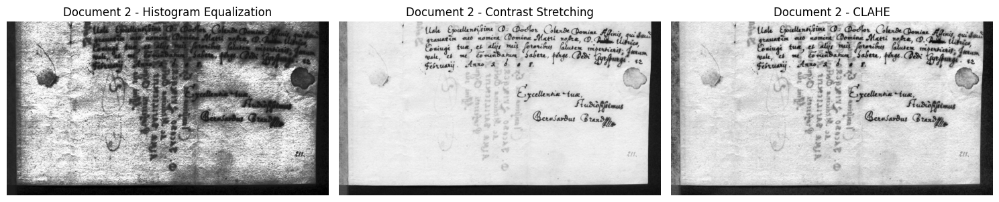

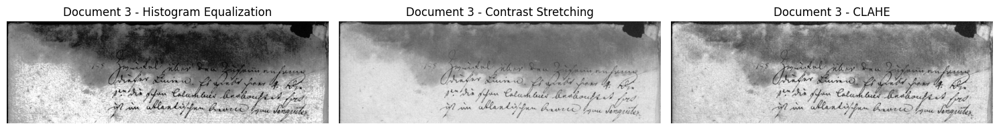

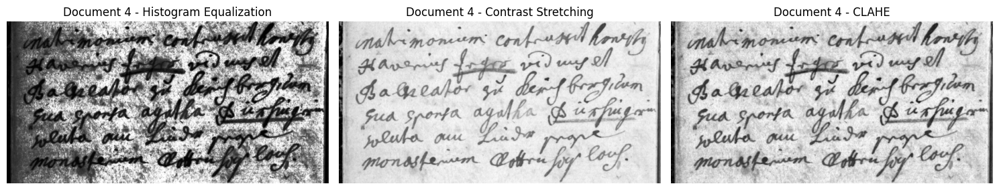

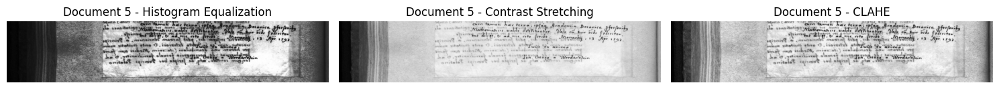

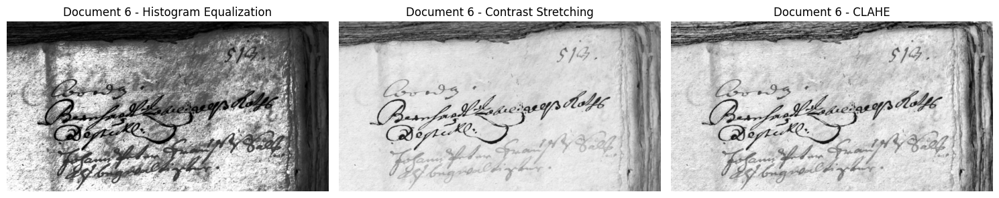

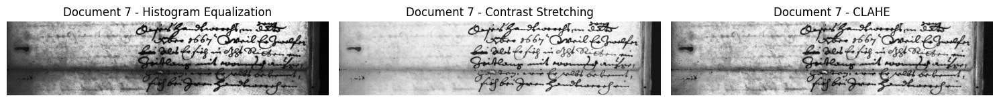

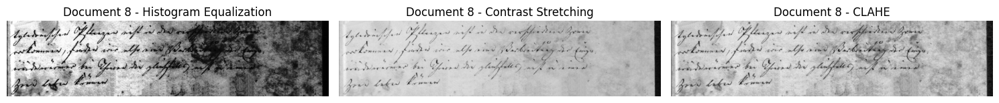

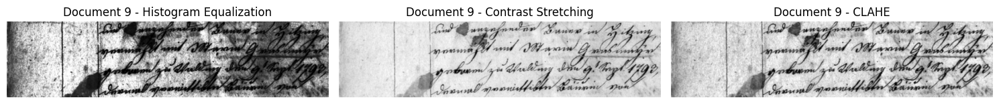

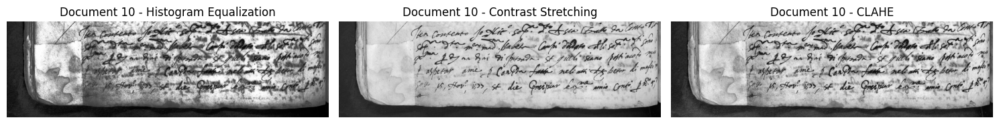

In [92]:
for i in range(10):

    hist = cv2.imread(
        hist_files[i],
        cv2.IMREAD_GRAYSCALE
    )

    stretch = cv2.imread(
        stretch_files[i],
        cv2.IMREAD_GRAYSCALE
    )

    clahe = cv2.imread(
        clahe_files[i],
        cv2.IMREAD_GRAYSCALE
    )

    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(hist, cmap="gray")
    plt.title(f"Document {i+1} - Histogram Equalization")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(stretch, cmap="gray")
    plt.title(f"Document {i+1} - Contrast Stretching")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(clahe, cmap="gray")
    plt.title(f"Document {i+1} - CLAHE")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [93]:
import numpy as np

def image_statistics(image):
    return {
        "mean": np.mean(image),
        "std": np.std(image),
        "min": np.min(image),
        "max": np.max(image)
    }

print("Histogram Equalization:")
print(image_statistics(hist1))

print("\nContrast Stretching:")
print(image_statistics(stretch1))

print("\nCLAHE:")
print(image_statistics(clahe1))

Histogram Equalization:
{'mean': np.float64(130.156544582725), 'std': np.float64(74.58443034663664), 'min': np.uint8(0), 'max': np.uint8(255)}

Contrast Stretching:
{'mean': np.float64(188.66868252556347), 'std': np.float64(25.972262433917983), 'min': np.uint8(0), 'max': np.uint8(255)}

CLAHE:
{'mean': np.float64(173.8773122515294), 'std': np.float64(37.87350953544905), 'min': np.uint8(1), 'max': np.uint8(248)}


In [94]:
import cv2
import numpy as np
import os
for i in range(10):

    hist = cv2.imread(
        hist_files[i],
        cv2.IMREAD_GRAYSCALE
    )
    stretch = cv2.imread(
        stretch_files[i],
        cv2.IMREAD_GRAYSCALE
    )
    clahe = cv2.imread(
        clahe_files[i],
        cv2.IMREAD_GRAYSCALE
    )
    # Resize to same dimensions if necessary
    h, w = hist.shape
    stretch = cv2.resize(
        stretch,
        (w, h)
    )
    clahe = cv2.resize(
        clahe,
        (w, h)
    )
    comparison = np.hstack([
        hist,
        stretch,
        clahe
    ])
    output_path = (
        f"member1_results/enhanced/"
        f"comparisons/document_{i+1}_comparison.bmp"
    )
    cv2.imwrite(
        output_path,
        comparison
    )
print("Comparison images created.")

Comparison images created.


##Overall Comparison Across 10 Documents

| Document | Histogram Equalization | Contrast Stretching | CLAHE |
|---|---|---|---|
| 1 | | | |
| 2 | | | |
| 3 | | | |
| 4 | | | |
| 5 | | | |
| 6 | | | |
| 7 | | | |
| 8 | | | |
| 9 | | | |
| 10 | | | |